<p style="background-color:#BCDBF9;color:black;font-size:25px;text-align:center;border-radius:10px 10px;font-weight:bold;">Tabular Playground Series - Nov 2021 ⚡</p>

<center><img src="https://media.giphy.com/media/xT9C25UNTwfZuk85WP/giphy-downsized-large.gif"></center>

<a id="section-one"></a>

##  <span style='font-size:22px;'>&#128311;</span>  Introduction

<font size="4">This dataset is synthetic, but based on a real dataset and generated using a CTGAN. The original dataset deals with predicting identifying spam emails via various extracted features from the email. Although the features are anonymized, they have properties relating to real-world features. The dataset has 100 features and the response variable is a binary variable.</font>


In [1]:
#importing librariaes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [3]:
train = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/train.csv')
test = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/test.csv')

print(train.shape)
print(test.shape)

(600000, 102)
(540000, 101)


In [4]:
train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,...,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,...,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,...,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,...,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,0
4,4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,...,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798,1


In [5]:
train.dtypes

id          int64
f0        float64
f1        float64
f2        float64
f3        float64
           ...   
f96       float64
f97       float64
f98       float64
f99       float64
target      int64
Length: 102, dtype: object

In [6]:
train=train.drop(['id'],1)
test=test.drop(['id'],1)

[(0, 296394), (1, 303606)]


<AxesSubplot:xlabel='target', ylabel='count'>

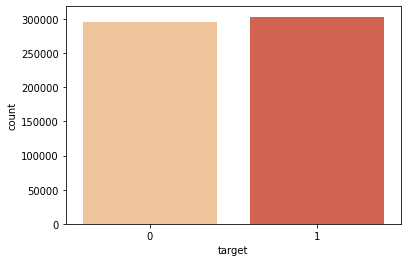

In [7]:
from collections import Counter
print(sorted(Counter(train['target']).items()))
sns.countplot(train['target'],palette='OrRd')

<AxesSubplot:>

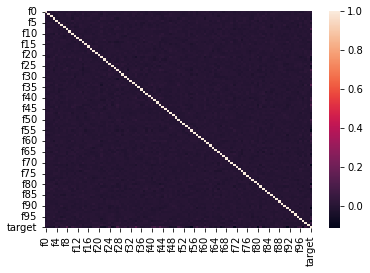

In [8]:
sns.heatmap(train.corr())

#### The varaibles are not correlated. all the values are very low.

<AxesSubplot:>

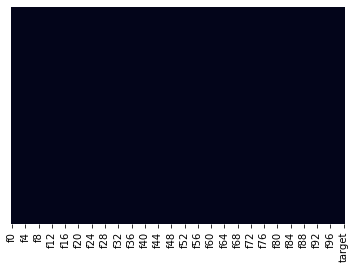

In [9]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False)

####  No missing values.

#### distributions before transformation

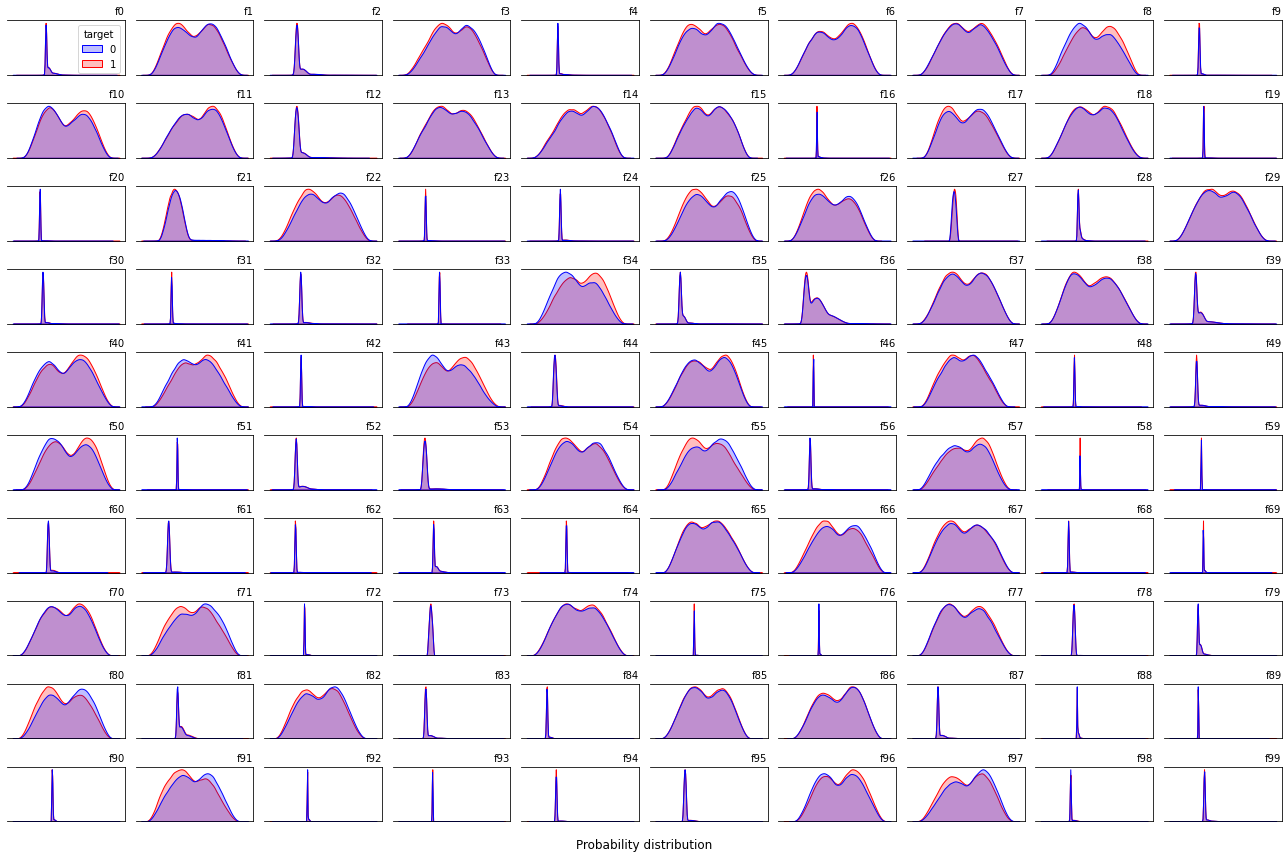

In [10]:
fig, axes = plt.subplots(10,10, figsize=(18, 12))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    
    sns.kdeplot(
        data=train, ax=ax, hue='target', fill=True,
        x=f'f{idx}', palette=['blue', 'red'], legend=idx==0
    )
 
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('')
    ax.set_ylabel(''); ax.spines['left'].set_visible(False)
    ax.set_title(f'f{idx}', loc='right',fontsize=10)

fig.supxlabel('Probability distribution', ha='center')
fig.tight_layout()
plt.show()

#### Before transforming data I will remove the target variable.

In [11]:
X=train.drop(['target'],1)
y=train['target']
test_x=test

In [12]:
#dividing the dataset into train and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=1234)

<a id="section-two"></a>

##  <span style='font-size:22px;'>&#127917;</span>  Data transformation

#### Quantile transforms are a technique for transforming numerical input or output variables to have a Gaussian or uniform probability distribution. here I am using normal quantile transformation.

In [13]:
from sklearn.preprocessing import QuantileTransformer
trans = QuantileTransformer(n_quantiles=100, output_distribution='normal')
trans.fit(x_train)
x_train_transformed = trans.transform(x_train)
x_test_transformed = trans.transform(x_test)
test_transformedf = trans.transform(test_x)

In [14]:
x_train_final = pd.DataFrame(x_train_transformed, columns = x_train.columns)
x_test_final = pd.DataFrame(x_test_transformed, columns = x_test.columns)
test_final=  pd.DataFrame(test_transformedf, columns = test.columns)

In [15]:
x_train_final['target']=y_train

#### distributions after transformations.

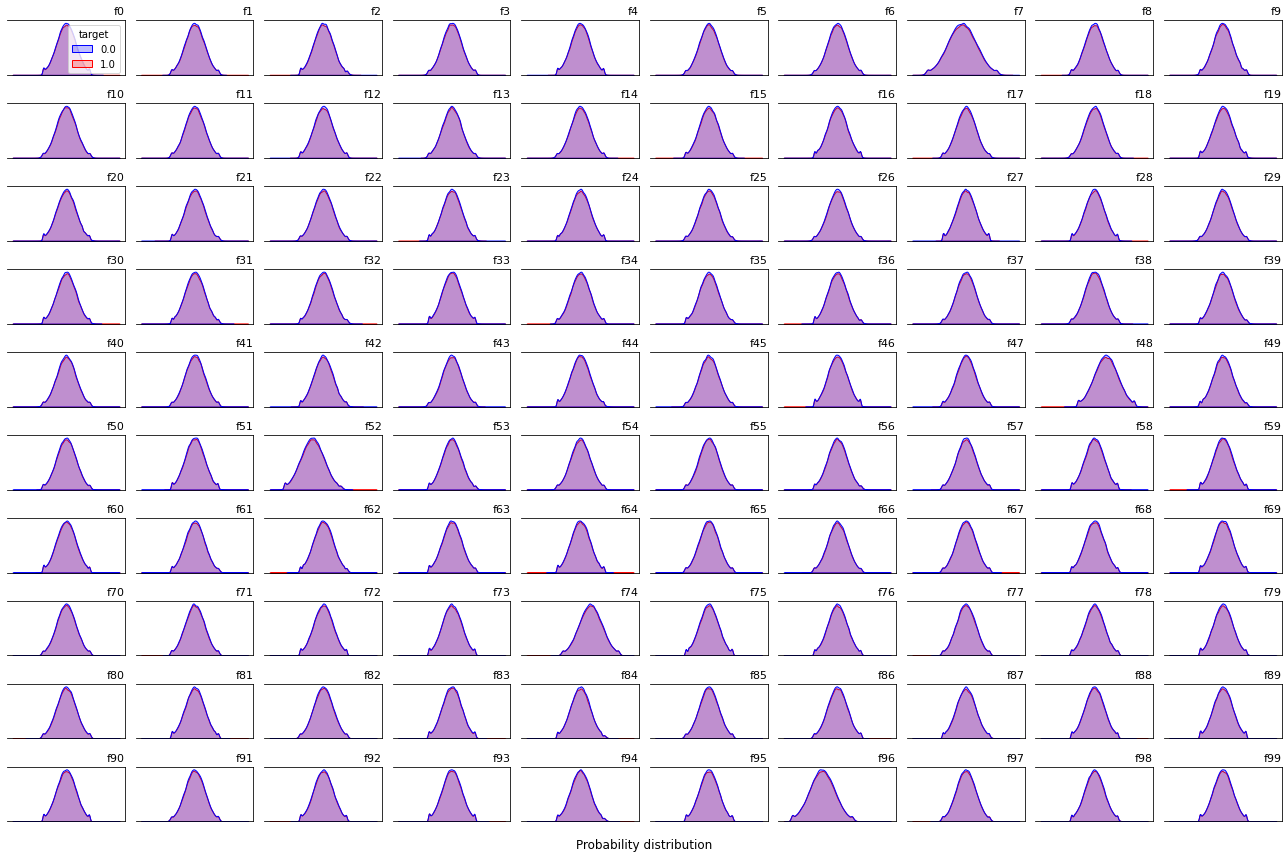

In [16]:
fig, axes = plt.subplots(10,10, figsize=(18, 12))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    
    sns.kdeplot(
        data=x_train_final, ax=ax, hue='target', fill=True,
        x=f'f{idx}', palette=['blue', 'red'], legend=idx==0
    )
 
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('')
    ax.set_ylabel(''); ax.spines['left'].set_visible(False)
    ax.set_title(f'f{idx}', loc='right', fontsize=11)

fig.supxlabel('Probability distribution', ha='center')
fig.tight_layout()
plt.show()

In [17]:
x_train_final.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,-0.602460,-0.367092,1.640960,0.136355,-1.176690,-0.487771,-0.354539,1.174423,-0.312183,-0.710245,...,-0.092229,-0.206088,1.180083,-0.269101,-0.001111,1.168595,-0.051440,-0.594597,1.964951,0.0
1,1.017369,1.022925,-0.376541,-1.324849,0.501049,-0.433307,-0.062761,-2.413907,0.298301,-0.881695,...,-0.809156,-0.891418,-1.004478,-0.565753,0.145019,-0.583725,-0.080103,-1.063196,-1.095635,0.0
2,-0.850416,1.117675,-0.892463,-1.297857,0.218054,-0.258132,-0.859742,-0.839648,-0.416127,1.525529,...,0.658134,-0.425538,-0.096298,-0.480353,-1.630478,1.544080,1.021228,-0.772001,-0.789292,0.0
3,0.612783,0.699108,1.468520,-0.742384,-0.962411,-0.151447,-0.377666,-2.356748,0.207764,2.183602,...,-1.547589,0.378609,1.693679,0.319544,0.004175,-1.750073,-1.789638,1.362242,-0.177178,0.0
4,-0.741944,0.523497,-0.624481,0.487829,-0.525393,-0.633990,-0.390627,0.676207,-0.225335,1.020757,...,0.310523,0.491715,1.222981,0.220377,-0.503760,0.061301,0.035269,1.253242,0.340679,1.0


In [18]:
x= x_train_final.drop(['target'],1)
y= y_train

#### This will be a very time consuming since the trainset is large. So I will use a sample from the train set randomly and check the accuracies. this will not reduce accuracies that much.

In [19]:
print(x.shape)
print(x_test.shape)

(480000, 100)
(120000, 100)


In [20]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.80,random_state=1234)

In [21]:
print(x_train1.shape)

(96000, 100)


<a id="section-three"></a>

##  <span style='font-size:22px;'>&#8987;</span> Model fitting

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

#libraries for model evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report

train accuracy: 0.70528125 
 test accuracy: 0.7085583333333333


classification report for logistic regression
              precision    recall  f1-score   support

           0       0.69      0.71      0.70     58015
           1       0.72      0.71      0.72     61985

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for logistic regression


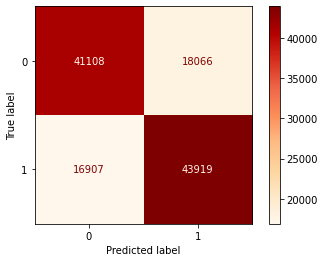

In [23]:
from sklearn.linear_model import RidgeClassifier
rc =RidgeClassifier()
model0=rc.fit(x_train1, y_train1)
print("train accuracy:",model0.score(x_train1, y_train1),"\n","test accuracy:",model0.score(x_test_final,y_test))
rcpred = rc.predict(x_test_final)
print("\n")
print("classification report for logistic regression")
print(classification_report(rcpred,y_test))
print("\n")
print("confusion matrix for logistic regression")
displr = plot_confusion_matrix(rc, x_test_final, y_test,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.7052291666666667 
 test accuracy: 0.7083916666666666


classification report for logistic regression
              precision    recall  f1-score   support

           0       0.69      0.71      0.70     58057
           1       0.72      0.71      0.71     61943

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for logistic regression


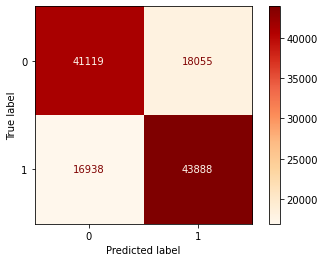

In [24]:
#logistic regression
lr = LogisticRegression(max_iter=20000,penalty='l2')
model1=lr.fit(x_train1, y_train1)
print("train accuracy:",model1.score(x_train1, y_train1),"\n","test accuracy:",model1.score(x_test_final,y_test))
lrpred = lr.predict(x_test_final)
print("\n")
print("classification report for logistic regression")
print(classification_report(lrpred,y_test))
print("\n")
print("confusion matrix for logistic regression")
displr = plot_confusion_matrix(lr, x_test_final, y_test,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.70528125 
 test accuracy: 0.7085583333333333


classification report for linear discriminant analysis
              precision    recall  f1-score   support

           0       0.69      0.71      0.70     58015
           1       0.72      0.71      0.72     61985

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for linear discriminant analysis


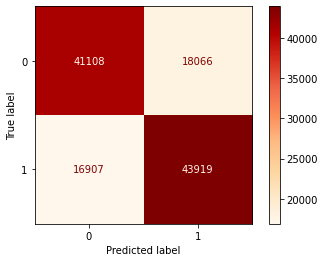

In [25]:
#linear discriminant analysis
lda = LinearDiscriminantAnalysis()
model2=lda.fit(x_train1, y_train1)
print("train accuracy:",model2.score(x_train1, y_train1),"\n","test accuracy:",model2.score(x_test_final,y_test))

ldapred = lda.predict(x_test_final)
print("\n")
print("classification report for linear discriminant analysis")
print(classification_report(ldapred,y_test))
print("\n")
print("confusion matrix for linear discriminant analysis")
displr = plot_confusion_matrix(lda, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 1.0 
 test accuracy: 0.544725


classification report for decision tree classifier
              precision    recall  f1-score   support

           0       0.54      0.54      0.54     59543
           1       0.55      0.55      0.55     60457

    accuracy                           0.54    120000
   macro avg       0.54      0.54      0.54    120000
weighted avg       0.54      0.54      0.54    120000



confusion matrix for decision tree classifier


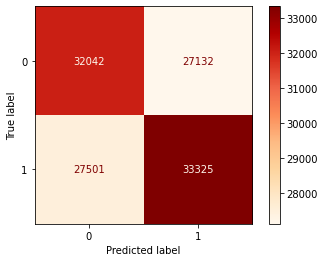

In [26]:
#decision tree classifier
dt=DecisionTreeClassifier()
model3=dt.fit(x_train1, y_train1)
print("train accuracy:",model3.score(x_train1, y_train1),"\n","test accuracy:",model3.score(x_test_final,y_test))

dtpred = dt.predict(x_test_final)
print("\n")
print("classification report for decision tree classifier")
print(classification_report(dtpred,y_test))
print("\n")
print("confusion matrix for decision tree classifier")
displr = plot_confusion_matrix(dt, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 1.0 
 test accuracy: 0.6557833333333334


classification report for random forest classifier
              precision    recall  f1-score   support

           0       0.65      0.65      0.65     58930
           1       0.66      0.66      0.66     61070

    accuracy                           0.66    120000
   macro avg       0.66      0.66      0.66    120000
weighted avg       0.66      0.66      0.66    120000



confusion matrix for random forest classifier


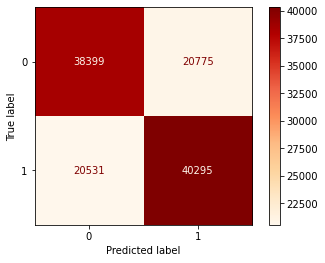

In [27]:
#random forest classifier
rf=RandomForestClassifier()
model4=rf.fit(x_train1, y_train1)
print("train accuracy:",model4.score(x_train1, y_train1),"\n","test accuracy:",model4.score(x_test_final,y_test))

rfpred = rf.predict(x_test_final)
print("\n")
print("classification report for random forest classifier")
print(classification_report(rfpred,y_test))
print("\n")
print("confusion matrix for random forest classifier")
displr = plot_confusion_matrix(rf, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.98715625 
 test accuracy: 0.58835


classification report for bagging classifier
              precision    recall  f1-score   support

           0       0.67      0.57      0.62     69806
           1       0.51      0.61      0.56     50194

    accuracy                           0.59    120000
   macro avg       0.59      0.59      0.59    120000
weighted avg       0.60      0.59      0.59    120000



confusion matrix for bagging classifier


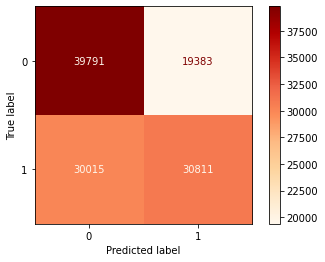

In [28]:
#bagging classifier
bg=BaggingClassifier()
model5=bg.fit(x_train1, y_train1)
print("train accuracy:",model5.score(x_train1, y_train1),"\n","test accuracy:",model5.score(x_test_final,y_test))

bgpred = bg.predict(x_test_final)
print("\n")
print("classification report for bagging classifier")
print(classification_report(bgpred,y_test))
print("\n")
print("confusion matrix for bagging classifier")
displr = plot_confusion_matrix(bg, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

<center><img src="https://media.giphy.com/media/3jmqIaBE8x86xwbSbD/giphy.gif"></center>

train accuracy: 0.6929375 
 test accuracy: 0.6767833333333333


classification report for gradient boosting classifier
              precision    recall  f1-score   support

           0       0.66      0.68      0.67     57388
           1       0.70      0.68      0.69     62612

    accuracy                           0.68    120000
   macro avg       0.68      0.68      0.68    120000
weighted avg       0.68      0.68      0.68    120000



confusion matrix for gradient boosting classifier


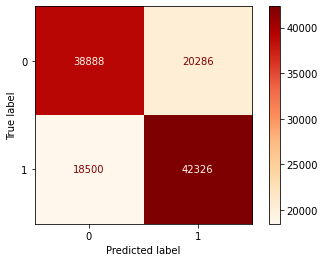

In [29]:
# gradient boost classifier 
gbm=GradientBoostingClassifier()
model6=gbm.fit(x_train1, y_train1)
print("train accuracy:",model6.score(x_train1, y_train1),"\n","test accuracy:",model6.score(x_test_final,y_test))

gbmpred = gbm.predict(x_test_final)
print("\n")
print("classification report for gradient boosting classifier")
print(classification_report(gbmpred,y_test))
print("\n")
print("confusion matrix for gradient boosting classifier")
displr = plot_confusion_matrix(gbm, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.6710208333333333 
 test accuracy: 0.6655166666666666


classification report for adaboost classifier
              precision    recall  f1-score   support

           0       0.65      0.66      0.66     58132
           1       0.68      0.67      0.67     61868

    accuracy                           0.67    120000
   macro avg       0.67      0.67      0.67    120000
weighted avg       0.67      0.67      0.67    120000



confusion matrix for adaboost classifier


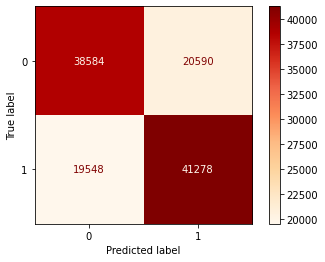

In [30]:
# adaboost classifier 
ada=AdaBoostClassifier()
model7=ada.fit(x_train1, y_train1)
print("train accuracy:",model7.score(x_train1, y_train1),"\n","test accuracy:",model7.score(x_test_final,y_test))

adapred = ada.predict(x_test_final)
print("\n")
print("classification report for adaboost classifier")
print(classification_report(adapred,y_test))
print("\n")
print("confusion matrix for adaboost classifier")
displr = plot_confusion_matrix(ada,x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

[02:27:42] WARNING: ../src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
train accuracy: 0.7991666666666667 
 test accuracy: 0.6735166666666667


classification report for extreme gradient boosting classifier
              precision    recall  f1-score   support

           0       0.66      0.67      0.67     58370
           1       0.68      0.68      0.68     61630

    accuracy                           0.67    120000
   macro avg       0.67      0.67      0.67    120000
weighted avg       0.67      0.67      0.67    120000



confusion matrix for extreme gradient boosting classifier


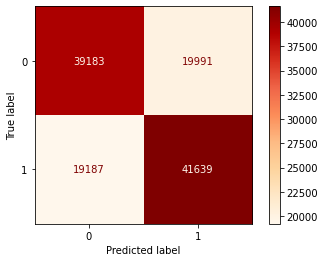

In [31]:
# extreme gradient boost classifier
xgb = XGBClassifier()
model8=xgb.fit(x_train1, y_train1)
print("train accuracy:",model8.score(x_train1, y_train1),"\n","test accuracy:",model8.score(x_test_final,y_test))

xgbpred = xgb.predict(x_test_final)
print("\n")
print("classification report for extreme gradient boosting classifier")
print(classification_report(xgbpred,y_test))
print("\n")
print("confusion matrix for extreme gradient boosting classifier")
displr = plot_confusion_matrix(xgb, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 1.0 
 test accuracy: 0.6467083333333333


classification report for extra tree classifier
              precision    recall  f1-score   support

           0       0.64      0.64      0.64     58911
           1       0.65      0.65      0.65     61089

    accuracy                           0.65    120000
   macro avg       0.65      0.65      0.65    120000
weighted avg       0.65      0.65      0.65    120000



confusion matrix for extra tree classifier


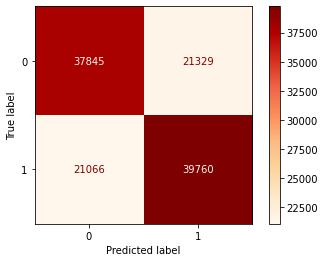

In [32]:
# extra tree classifier
extree = ExtraTreesClassifier()
model9=extree.fit(x_train1, y_train1)
print("train accuracy:",model9.score(x_train1, y_train1),"\n","test accuracy:",model9.score(x_test_final,y_test))

extpred = extree.predict(x_test_final)
print("\n")
print("classification report for extra tree classifier")
print(classification_report(extpred,y_test))
print("\n")
print("confusion matrix for extra tree classifier")
displr = plot_confusion_matrix(extree, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.7051875 
 test accuracy: 0.708475


classification report for voting classifier
              precision    recall  f1-score   support

           0       0.69      0.71      0.70     58039
           1       0.72      0.71      0.72     61961

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for voting classifier


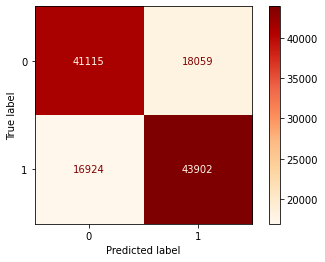

In [33]:
# voting classifer
from sklearn.ensemble import VotingClassifier
clf1 = LinearDiscriminantAnalysis()
clf2 = LogisticRegression(max_iter=20000,penalty='l2')

vc = VotingClassifier(estimators=[('ext', clf1),('lr', clf2)], voting='soft')
model10=vc.fit(x_train1, y_train1)
print("train accuracy:",model10.score(x_train1, y_train1),"\n","test accuracy:",model10.score(x_test_final,y_test))

vcpred = vc.predict(x_test_final)
print("\n")
print("classification report for voting classifier")
print(classification_report(vcpred,y_test))
print("\n")
print("confusion matrix for voting classifier")
displr = plot_confusion_matrix(vc, x_test_final, y_test ,cmap=plt.cm.OrRd, values_format='d')

train accuracy: 0.7053645833333333 
 test accuracy: 0.7084333333333334


classification report for voting classifier
              precision    recall  f1-score   support

           0       0.70      0.71      0.70     58126
           1       0.72      0.71      0.71     61874

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for voting classifier


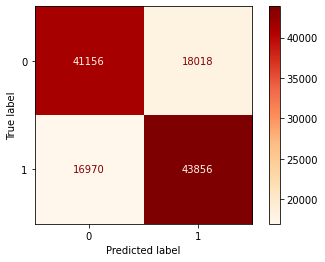

In [34]:
# stacking classifier 
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

estimators = [('rf',make_pipeline(StandardScaler(),LinearDiscriminantAnalysis()) ),('ext', make_pipeline(StandardScaler(),LogisticRegression(max_iter=20000,penalty='l2')))]
sc= StackingClassifier( estimators=estimators)

model11=sc.fit(x_train1, y_train1)
print("train accuracy:",model11.score(x_train1, y_train1),"\n","test accuracy:",model11.score(x_test_final,y_test))

scpred = sc.predict(x_test_final)
print("\n")
print("classification report for voting classifier")
print(classification_report(scpred,y_test))
print("\n")
print("confusion matrix for voting classifier")
displr = plot_confusion_matrix(sc, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.7875 
 test accuracy: 0.709125


classification report for extra tree classifier
              precision    recall  f1-score   support

           0       0.70      0.71      0.70     58247
           1       0.72      0.71      0.72     61753

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for extra tree classifier


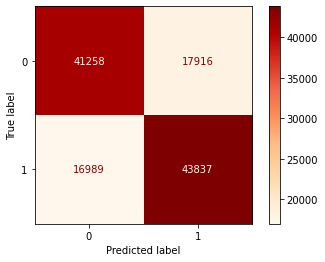

In [35]:
from catboost import CatBoostClassifier

cc = CatBoostClassifier(silent=True )
model12=cc.fit(x_train1, y_train1)
print("train accuracy:",model12.score(x_train1, y_train1),"\n","test accuracy:",model12.score(x_test_final,y_test))

ccpred = cc.predict(x_test_final)
print("\n")
print("classification report for extra tree classifier")
print(classification_report(ccpred,y_test))
print("\n")
print("confusion matrix for extra tree classifier")
displr = plot_confusion_matrix(cc, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

#### since catboost classifier has the highest accuracy.let's check that with original training set.

train accuracy: 0.7495020833333333 
 test accuracy: 0.7158416666666667


classification report for extra tree classifier
              precision    recall  f1-score   support

           0       0.71      0.71      0.71     58607
           1       0.72      0.72      0.72     61393

    accuracy                           0.72    120000
   macro avg       0.72      0.72      0.72    120000
weighted avg       0.72      0.72      0.72    120000



confusion matrix for extra tree classifier


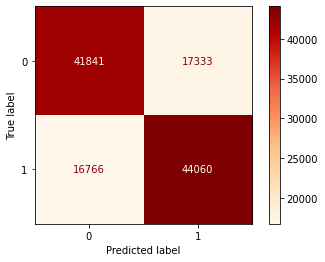

In [36]:
ccf = CatBoostClassifier(silent=True )
model13=ccf.fit(x, y_train)
print("train accuracy:",model13.score(x, y_train),"\n","test accuracy:",model13.score(x_test_final,y_test))

ccfpred = ccf.predict(x_test_final)
print("\n")
print("classification report for extra tree classifier")
print(classification_report(ccfpred,y_test))
print("\n")
print("confusion matrix for extra tree classifier")
displr = plot_confusion_matrix(ccf, x_test_final, y_test ,cmap=plt.cm.OrRd , values_format='d')

<a id="section-four"></a>

##  <span style='font-size:22px;'>&#128202;</span>  Feature Importance plot

#### Feature importance plot from the catboost classifier model.

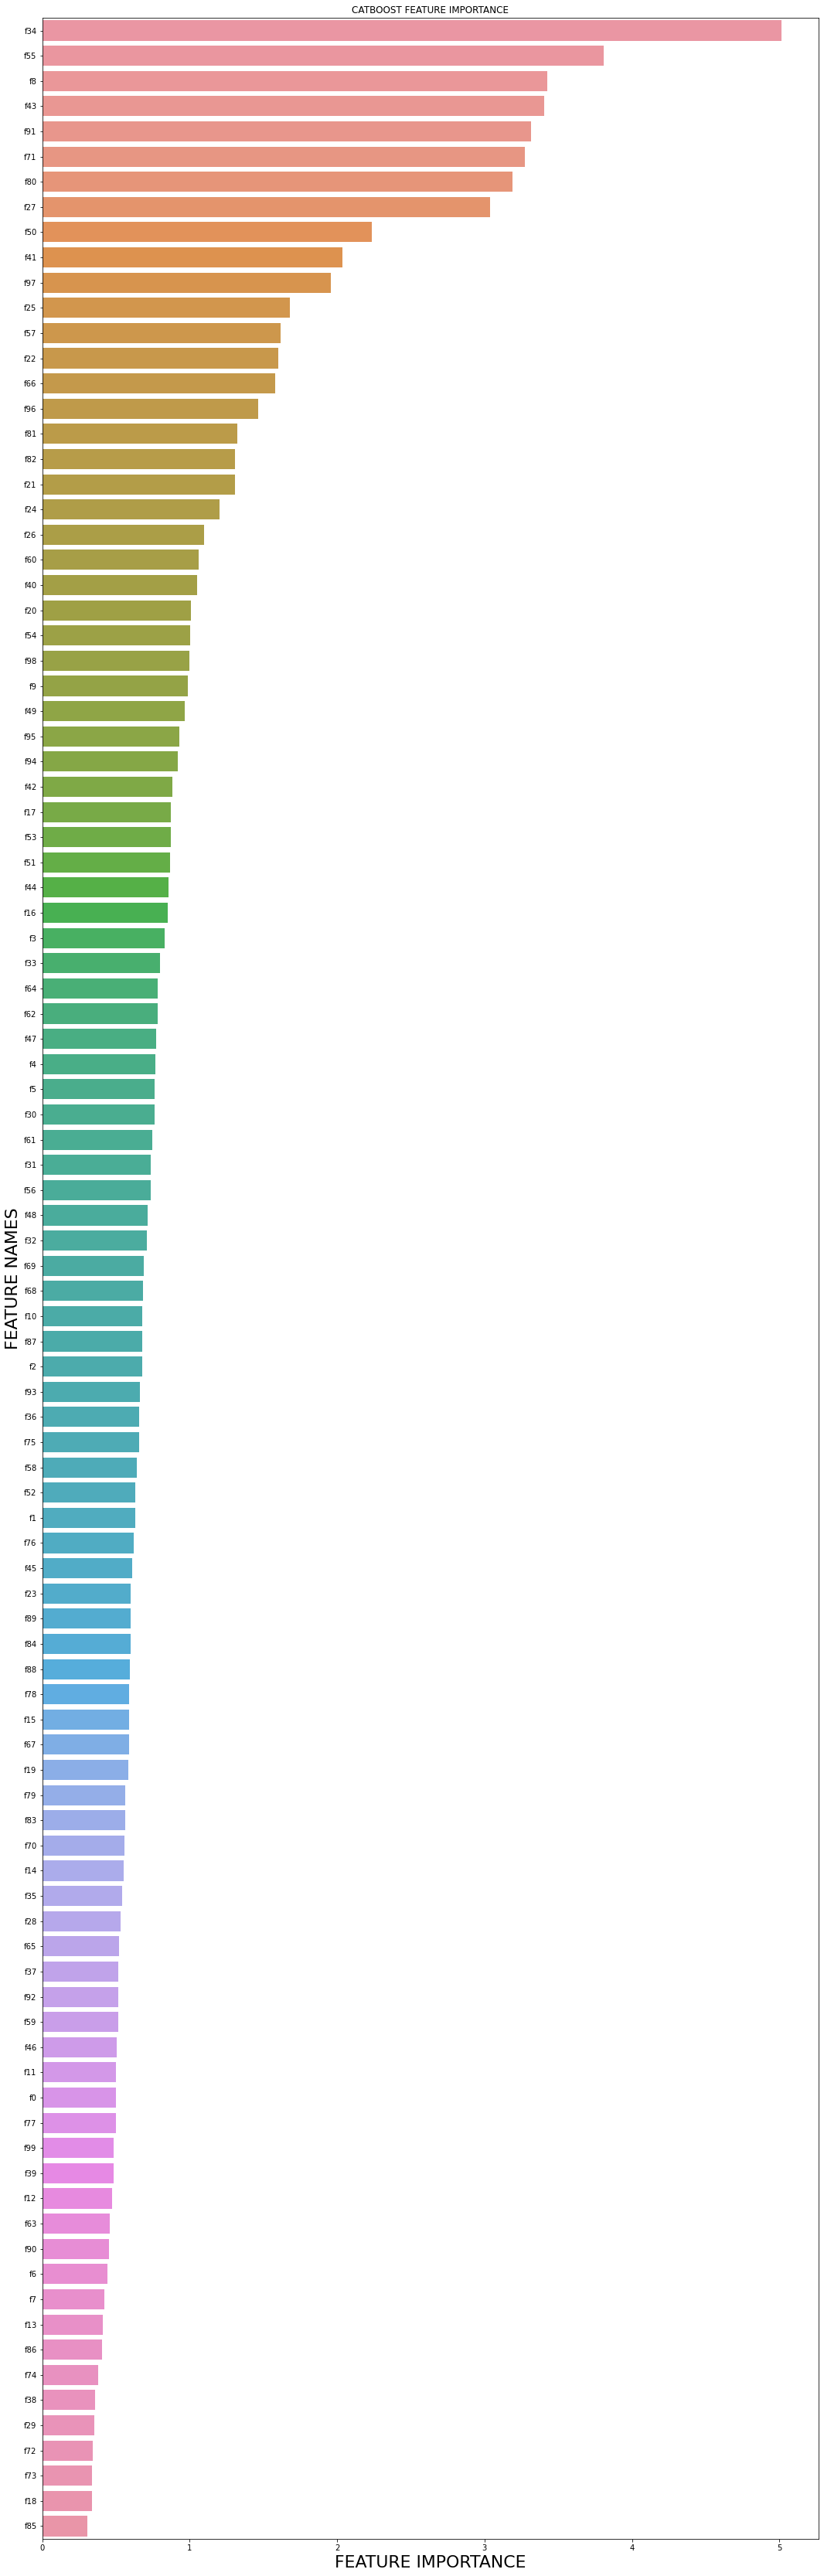

In [37]:
def plot_feature_importance(importance,names,model_type):    

    #Create arrays from feature importance and feature names
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    #Create a DataFrame using a Dictionary
    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)
    
    #Sort the DataFrame in order decreasing feature importance
    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    #Define size of bar plot
    plt.figure(figsize=(18,60))
    #Plot Searborn bar chart
    sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
    #Add chart labels
    plt.title(model_type + ' FEATURE IMPORTANCE')
    plt.xlabel('FEATURE IMPORTANCE', fontsize=22)
    plt.ylabel('FEATURE NAMES', fontsize=22)
    
plot_feature_importance(ccf.get_feature_importance(),x.columns,'CATBOOST')

#### Now let's fit the model with only important variables.

In [38]:
cols=['f34','f55','f8','f43','f91','f71','f80','f27','f50','f97','f41','f57','f22','f25','f66','f96','f81','f82','f21','f24','f26','f54',
     'f60','f95','f20','f40','f98','f9','f33','f53','f94','f31','f17','f51','f3','f16','f62','f44','f30','f42','f5','f49','f48','f64',
     'f2','f56','f32','f93','f68','f4','f87','f10','f61','f1','f47','f75','f23','f84','f58','f70','f76','f83','f36','f99','f78','f88']

In [39]:
df = x.filter(cols)
#df_test=test_transformedf.filter(cols)

In [40]:
df.head()

,f34,f55,f8,f43,f91,f71,f80,f27,f50,f97,...,f23,f84,f58,f70,f76,f83,f36,f99,f78,f88
0,0.419075,-0.701296,-0.312183,0.882156,-0.092229,-1.599302,-0.069073,0.601053,-0.498439,-0.051440,...,0.427301,0.485137,1.528009,-1.192578,0.325149,-0.358201,-0.358041,1.964951,1.383284,1.198704
1,-0.528385,0.181605,0.298301,1.468321,-0.809156,0.102940,-0.143600,-0.233263,-0.254934,-0.080103,...,-0.909102,-1.104302,-0.488915,0.874544,0.640800,-0.946288,0.025876,-1.095635,-0.142552,2.127621
2,-0.717871,0.171026,-0.416127,0.434443,0.658134,0.624262,0.981334,1.902955,-1.799895,1.021228,...,-0.193214,0.674371,-0.013150,1.033329,0.802716,1.769864,0.034648,-0.789292,-0.818835,-0.080002
3,1.111804,-0.835396,0.207764,-1.234170,-1.547589,1.966767,0.105150,1.390914,0.762391,-1.789638,...,-1.265957,1.459183,-0.968895,0.368512,0.019808,0.820671,-0.518709,-0.177178,0.128471,-0.252901
4,1.803058,-0.923599,-0.225335,-1.698459,0.310523,0.667681,-1.953150,0.004515,0.468565,0.035269,...,-0.829458,0.296064,0.744021,-0.666876,0.154030,0.792365,0.051003,0.340679,-0.912639,1.236467


In [41]:
df.shape

(480000, 66)

In [42]:
x_train_imp,x_test_imp,y_train_imp,y_test_imp=train_test_split(df,y,test_size=0.20,random_state=1234)

train accuracy: 0.7463541666666667 
 test accuracy: 0.7109583333333334


classification report for extra tree classifier
              precision    recall  f1-score   support

           0       0.70      0.71      0.71     46757
           1       0.72      0.71      0.72     49243

    accuracy                           0.71     96000
   macro avg       0.71      0.71      0.71     96000
weighted avg       0.71      0.71      0.71     96000



confusion matrix for extra tree classifier


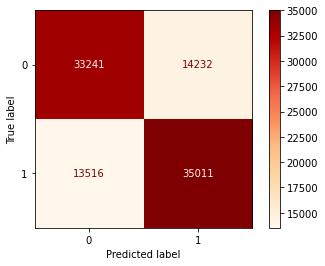

In [43]:
ccimp = CatBoostClassifier(silent=True )
model14=ccimp.fit(x_train_imp, y_train_imp)
print("train accuracy:",model14.score(x_train_imp, y_train_imp),"\n","test accuracy:",model14.score(x_test_imp,y_test_imp))

ccimppred = ccimp.predict(x_test_imp)
print("\n")
print("classification report for extra tree classifier")
print(classification_report(ccimppred,y_test_imp))
print("\n")
print("confusion matrix for extra tree classifier")
displr = plot_confusion_matrix(ccimp, x_test_imp, y_test_imp ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.7017786458333334 
 test accuracy: 0.703125


classification report for logistic regression
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     46579
           1       0.72      0.70      0.71     49421

    accuracy                           0.70     96000
   macro avg       0.70      0.70      0.70     96000
weighted avg       0.70      0.70      0.70     96000



confusion matrix for logistic regression


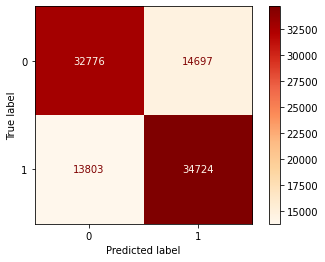

In [44]:
from sklearn.linear_model import RidgeClassifier
rcimp =RidgeClassifier()
model15=rcimp.fit(x_train_imp, y_train_imp)
print("train accuracy:",model15.score(x_train_imp, y_train_imp),"\n","test accuracy:",model15.score(x_test_imp,y_test_imp))
rcimppred = rcimp.predict(x_test_imp)
print("\n")
print("classification report for logistic regression")
print(classification_report(rcimppred,y_test_imp))
print("\n")
print("confusion matrix for logistic regression")
displr = plot_confusion_matrix(rcimp, x_test_imp, y_test_imp,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.7017161458333333 
 test accuracy: 0.7032395833333334


classification report for stacking classifier
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     46654
           1       0.71      0.70      0.71     49346

    accuracy                           0.70     96000
   macro avg       0.70      0.70      0.70     96000
weighted avg       0.70      0.70      0.70     96000



confusion matrix for stacking classifier


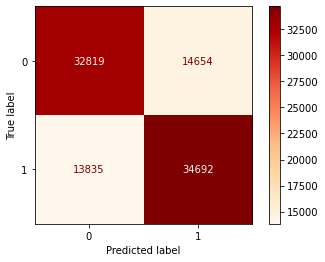

In [45]:
# stacking classifier 
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

estimators = [('rf',make_pipeline(StandardScaler(),LinearDiscriminantAnalysis()) ),('ext', make_pipeline(StandardScaler(),LogisticRegression(max_iter=20000,penalty='l2')))]
scimp= StackingClassifier( estimators=estimators)

model16=scimp.fit(x_train_imp, y_train_imp)
print("train accuracy:",model16.score(x_train_imp, y_train_imp),"\n","test accuracy:",model16.score(x_test_imp,y_test_imp))

scimppred = scimp.predict(x_test_imp)
print("\n")
print("classification report for stacking classifier")
print(classification_report(scimppred,y_test_imp))
print("\n")
print("confusion matrix for stacking classifier")
displr = plot_confusion_matrix(scimp, x_test_imp, y_test_imp ,cmap=plt.cm.OrRd , values_format='d')

train accuracy: 0.7017786458333334 
 test accuracy: 0.70309375


classification report for voting classifier
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     46602
           1       0.72      0.70      0.71     49398

    accuracy                           0.70     96000
   macro avg       0.70      0.70      0.70     96000
weighted avg       0.70      0.70      0.70     96000



confusion matrix for voting classifier


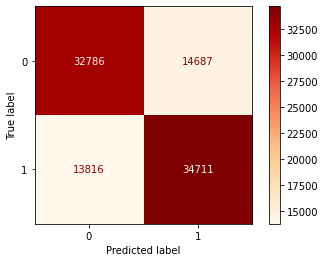

In [46]:
# voting classifer
from sklearn.ensemble import VotingClassifier
clf1 = LinearDiscriminantAnalysis()
clf2 = LogisticRegression(max_iter=20000,penalty='l2')

vcimp = VotingClassifier(estimators=[('lda', clf1),('lr', clf2)], voting='soft')
model17=vcimp.fit(x_train_imp, y_train_imp)
print("train accuracy:",model17.score(x_train_imp, y_train_imp),"\n","test accuracy:",model17.score(x_test_imp,y_test_imp))

vcimppred = vcimp.predict(x_test_imp)
print("\n")
print("classification report for voting classifier")
print(classification_report(vcimppred,y_test_imp))
print("\n")
print("confusion matrix for voting classifier")
displr = plot_confusion_matrix(vcimp, x_test_imp, y_test_imp ,cmap=plt.cm.OrRd, values_format='d')

##  <span style='font-size:22px;'>&#128142;</span>  Results

<font size="4"> Feature selection has helped to reduce over fitting but the expected performance coud not found. The highest accuracy was getting by <span style="color:red;">linear models and catboost classifiers</span>. The highest accuracy achieved is <span style="color:red;">71.65%</span></font>


<center><img src="https://media.giphy.com/media/j1Xyt3DHfJcmk/giphy.gif"></center>

<font size="4"><b> Any suggestions,questions or feedback regarding this notebook are highly appreciated. THANK YOU <span style='font-size:22px;'>&#128522;</span> <b></font>

<font size="5"> </font>